# 🎵 Análise Exploratória: Fatores Associados ao Sucesso Musical no Spotify — 2023

## 📌 Resumo dos resultados

A análise indica que as características musicais apresentam associações fracas com o número de streams, enquanto métricas relacionadas à presença em playlists e plataformas apresentam associações consideravelmente mais fortes.

Entre as variáveis analisadas, a presença em playlists do Spotify e da Apple Music apresenta algumas das maiores correlações com streams.

Esses resultados indicam uma forte associação entre exposição e desempenho observado, mas não permitem afirmar uma relação causal.

## 🎯 Objetivo

Este projeto tem como objetivo explorar quais fatores estão associados ao desempenho das músicas presentes no ranking do Spotify em 2023.

A análise considera três dimensões principais:

- 🎧 **Características musicais** — energia, dançabilidade, valência, acústica, BPM etc.
- 📈 **Distribuição e presença em plataformas** — playlists e rankings de diferentes serviços.
- 👤 **Artistas e lançamentos** — frequência de aparição no ranking e período de lançamento.

### Pergunta principal

> **Quais características estão mais associadas ao número de streams das músicas presentes no ranking de 2023?**

### Hipóteses investigadas

1. Características musicais apresentam associação relevante com o número de streams.
2. Presença em playlists está associada a maior volume de streams.
3. Alguns artistas concentram uma parcela relevante das músicas presentes no ranking.
4. O período de lançamento apresenta diferenças no desempenho das faixas.

### 🛠️ Tecnologias

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### 📊 Fonte dos dados

Dataset de músicas do Spotify disponibilizado no Kaggle.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option('display.float_format', '{:,.2f}'.format)

## 1. Carregamento da base

A base contém informações sobre músicas presentes no ranking do Spotify em 2023, incluindo dados de reprodução, características musicais, presença em playlists e rankings de outras plataformas.

A codificação `ISO-8859-1` é utilizada para preservar corretamente caracteres especiais presentes nos nomes de músicas e artistas.

In [8]:
from pathlib import Path

DATA_PATH = Path("../data/spotify-2023.csv")

df = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1"
)
df.head()

Mounted at /content/drive


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## 2. Inspeção Estrutural
Vamos verificar a quantidade de linhas, colunas e os tipos de dados de cada atributo para identificar possíveis inconsistências

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [10]:
print(f"Linhas: {df.shape[0]:,}")
print(f"Colunas: {df.shape[1]:,}")

Linhas: 953
Colunas: 24


In [11]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## 3. Qualidade e preparação dos dados

Antes de iniciar a análise, serão verificadas:

- inconsistências nos tipos de dados;
- valores ausentes;
- duplicidades;
- valores fora das faixas esperadas;
- variáveis numéricas armazenadas como texto.

O objetivo é garantir que as análises posteriores sejam realizadas sobre dados em formatos adequados.

In [12]:
# Colunas que representam valores numéricos
colunas_numericas = [
    'streams',
    'in_spotify_playlists',
    'in_spotify_charts',
    'in_apple_playlists',
    'in_apple_charts',
    'in_deezer_playlists',
    'in_deezer_charts',
    'in_shazam_charts'
]

for coluna in colunas_numericas:
    df[coluna] = (
        df[coluna]
        .astype(str)
        .str.replace(',', '', regex=False)
        .replace('nan', np.nan)
    )

    df[coluna] = pd.to_numeric(
        df[coluna],
        errors='coerce'
    )

In [13]:
nulos = df.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0]

,0
key,95
in_shazam_charts,50
streams,1


In [14]:
percentual_nulos = (
    df.isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

percentual_nulos[percentual_nulos > 0]

,0
key,9.97
in_shazam_charts,5.25
streams,0.10


Verifica duplicatas

In [15]:
df.duplicated().sum()

np.int64(0)

Verifica se existem duas musicas com o mesmo nome

In [16]:
df['track_name'].duplicated().sum()


np.int64(10)

In [17]:
duplicadas= df[df['track_name'].duplicated(keep=False)].sort_values(by='track_name')
duplicadas

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
764,About Damn Time,Lizzo,1,2022,4,14,9021,0,"723,894,473.00",242,...,109,A#,Minor,84,72,74,10,0,34,7
372,About Damn Time,Lizzo,1,2022,7,15,2332,2,"723,894,473.00",0,...,109,A#,Minor,84,72,74,10,0,34,7
13,Daylight,David Kushner,1,2023,4,14,3528,98,"387,570,742.00",80,...,130,D,Minor,51,32,43,83,0,9,3
831,Daylight,Harry Styles,1,2022,5,20,2775,0,"290,833,204.00",21,...,146,NaN,Major,69,63,45,48,0,18,4
47,Die For You,The Weeknd,1,2016,11,24,2483,59,"1,647,990,401.00",68,...,134,C#,Minor,59,51,52,9,0,15,7
417,Die For You,Joji,1,2022,11,4,1703,0,"246,390,068.00",38,...,148,G#,Major,47,15,52,38,13,29,5
12,Flowers,Miley Cyrus,1,2023,1,12,12211,115,"1,316,855,716.00",300,...,118,NaN,Major,71,65,68,6,0,3,7
825,Flowers,Lauren Spencer Smith,1,2021,8,9,801,0,"184,826,429.00",42,...,138,D#,Major,70,31,44,84,0,9,39
466,Let It Snow! Let It Snow! Let It Snow!,"Frank Sinatra, B. Swanson Quartet",2,1950,1,1,10585,0,"473,248,298.00",126,...,143,D,Major,60,86,32,88,0,34,6
448,Let It Snow! Let It Snow! Let It Snow!,Dean Martin,1,1959,11,16,6512,0,"446,390,129.00",88,...,134,C#,Major,45,72,24,91,0,18,4


remove duplicatas

In [18]:
df = df.drop_duplicates(subset=['track_name', 'artist(s)_name']).reset_index(drop=True)

Tratando Streams

In [19]:
print("Linhas sem streams:", df['streams'].isna().sum())

Linhas sem streams: 1


In [20]:
df = df.dropna(subset=['streams']).copy()

Verificando os tons das musicas

In [21]:
print(
    f"Valores ausentes em 'key': "
    f"{df['key'].isna().sum()}"
)

Valores ausentes em 'key': 94


In [22]:
colunas_percentuais = [
    'danceability_%',
    'energy_%',
    'valence_%',
    'acousticness_%',
    'instrumentalness_%',
    'liveness_%',
    'speechiness_%'
]

df[colunas_percentuais].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability_%,948.00,66.97,14.64,23.00,57.00,69.00,78.00,96.00
energy_%,948.00,64.26,16.59,9.00,53.00,66.00,77.00,97.00
valence_%,948.00,51.38,23.52,4.00,32.00,51.00,70.00,97.00
acousticness_%,948.00,27.16,26.03,0.00,6.00,18.00,43.00,97.00
instrumentalness_%,948.00,1.57,8.41,0.00,0.00,0.00,0.00,91.00
liveness_%,948.00,18.18,13.71,3.00,10.00,12.00,23.25,97.00
speechiness_%,948.00,10.15,9.93,2.00,4.00,6.00,11.00,64.00


In [23]:
for coluna in colunas_percentuais:
    fora_da_faixa = (
        (df[coluna] < 0) |
        (df[coluna] > 100)
    ).sum()

    print(f"{coluna}: {fora_da_faixa} valores fora da faixa")

danceability_%: 0 valores fora da faixa
energy_%: 0 valores fora da faixa
valence_%: 0 valores fora da faixa
acousticness_%: 0 valores fora da faixa
instrumentalness_%: 0 valores fora da faixa
liveness_%: 0 valores fora da faixa
speechiness_%: 0 valores fora da faixa


## 4. Perfil dos artistas

Nesta etapa, analisaremos a distribuição das principais características dos artistas das faixas.

O objetivo inicial é entender o perfil dos artistas presentes no ranking, sem assumir que determinada característica seja responsável pelo sucesso.

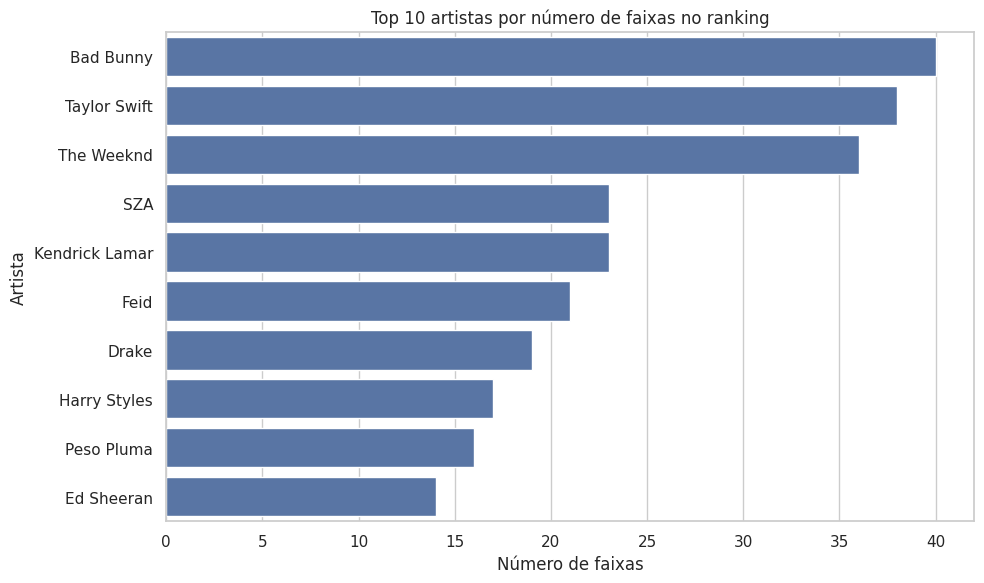

In [24]:
artistas = (
    df['artist(s)_name']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)

top_artistas = artistas.value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_artistas.values,
    y=top_artistas.index
)

plt.title('Top 10 artistas por número de faixas no ranking')
plt.xlabel('Número de faixas')
plt.ylabel('Artista')

plt.tight_layout()
plt.show()

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
artist_count,948.00,1.56,0.89,1.00,1.00,1.00,2.00,8.00
released_year,948.00,"2,018.27",11.03,"1,930.00","2,020.00","2,022.00","2,022.00","2,023.00"
released_month,948.00,6.04,3.57,1.00,3.00,6.00,9.00,12.00
released_day,948.00,13.93,9.19,1.00,6.00,13.00,22.00,31.00
in_spotify_playlists,948.00,"5,205.74","7,914.81",31.00,874.50,"2,216.50","5,503.75","52,898.00"
in_spotify_charts,948.00,12.07,19.61,0.00,0.00,3.00,16.00,147.00
streams,948.00,"514,017,927.52","567,927,731.75","2,762.00","141,143,862.00","287,690,252.00","672,942,469.00","3,703,895,074.00"
in_apple_playlists,948.00,67.71,86.35,0.00,13.00,34.00,87.25,672.00
in_apple_charts,948.00,52.05,50.67,0.00,7.00,38.50,87.00,275.00
in_deezer_playlists,948.00,386.43,"1,133.35",0.00,13.00,44.00,164.00,"12,367.00"


## 5. Análise de Características Musicais (Danceability, Energy e Valence)
Agora vamos explorar as características musicais das faixas para entender quais padrões e perfis sonoros (como dançabilidade, energia e positividade) predominam entre as músicas mais populares de 2023.

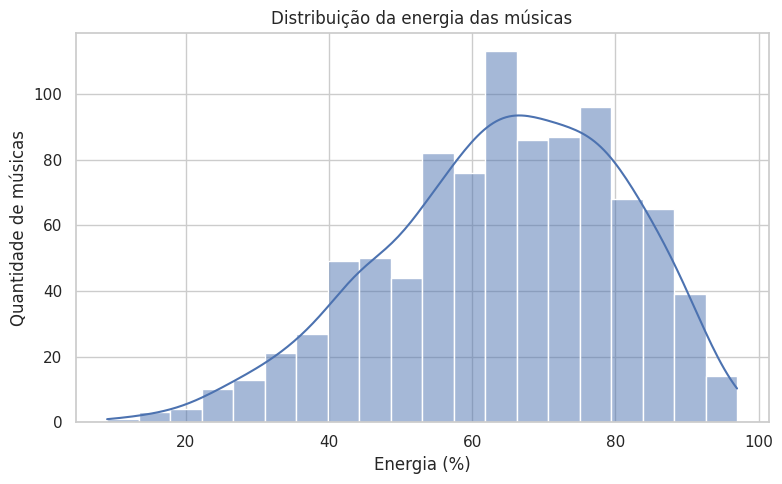

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='energy_%',
    bins=20,
    kde=True
)

plt.title('Distribuição da energia das músicas')
plt.xlabel('Energia (%)')
plt.ylabel('Quantidade de músicas')

plt.tight_layout()
plt.show()

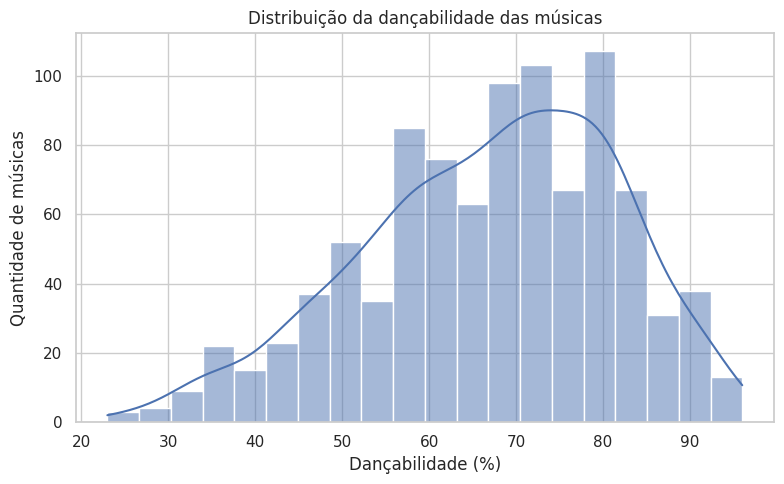

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='danceability_%',
    bins=20,
    kde=True
)

plt.title('Distribuição da dançabilidade das músicas')
plt.xlabel('Dançabilidade (%)')
plt.ylabel('Quantidade de músicas')

plt.tight_layout()
plt.show()

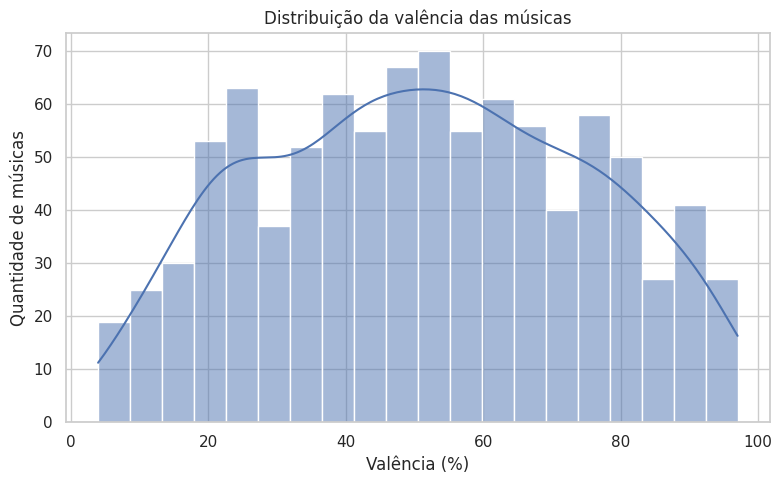

In [28]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='valence_%',
    bins=20,
    kde=True
)

plt.title('Distribuição da valência das músicas')
plt.xlabel('Valência (%)')
plt.ylabel('Quantidade de músicas')

plt.tight_layout()
plt.show()

In [29]:
df['energy_faixa'] = pd.cut(
    df['energy_%'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=[
        '0–20',
        '21–40',
        '41–60',
        '61–80',
        '81–100'
    ],
    include_lowest=True
)

energia_streams = (
    df.groupby('energy_faixa', observed=True)['streams']
    .agg(['mean', 'median', 'count'])
)

energia_streams

,mean,median,count
energy_faixa,,,
0–20,"195,850,643.50","161,587,617.50",8
21–40,"584,103,397.48","317,726,339.00",79
41–60,"525,023,188.26","308,512,063.00",276
61–80,"522,954,523.59","294,352,144.00",421
81–100,"454,315,654.55","240,789,594.50",164


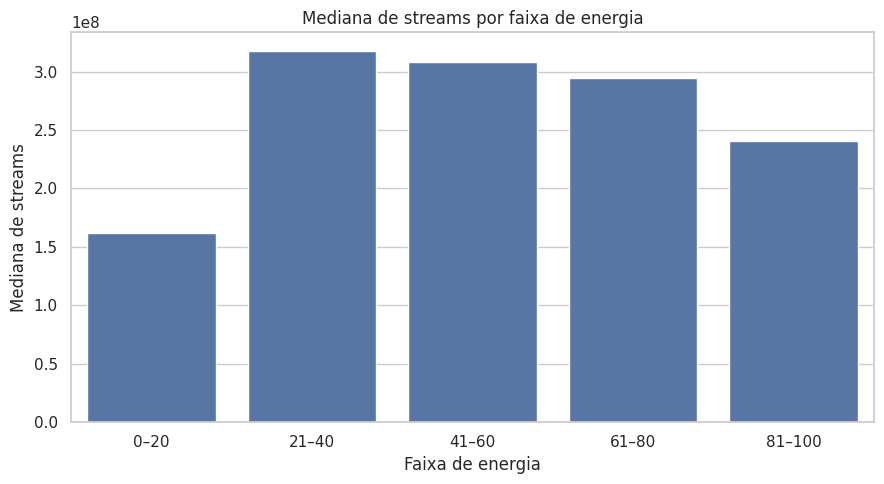

In [30]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=energia_streams.reset_index(),
    x='energy_faixa',
    y='median'
)

plt.title('Mediana de streams por faixa de energia')
plt.xlabel('Faixa de energia')
plt.ylabel('Mediana de streams')

plt.tight_layout()
plt.show()

 Top 10 musicas mais populares de 2023

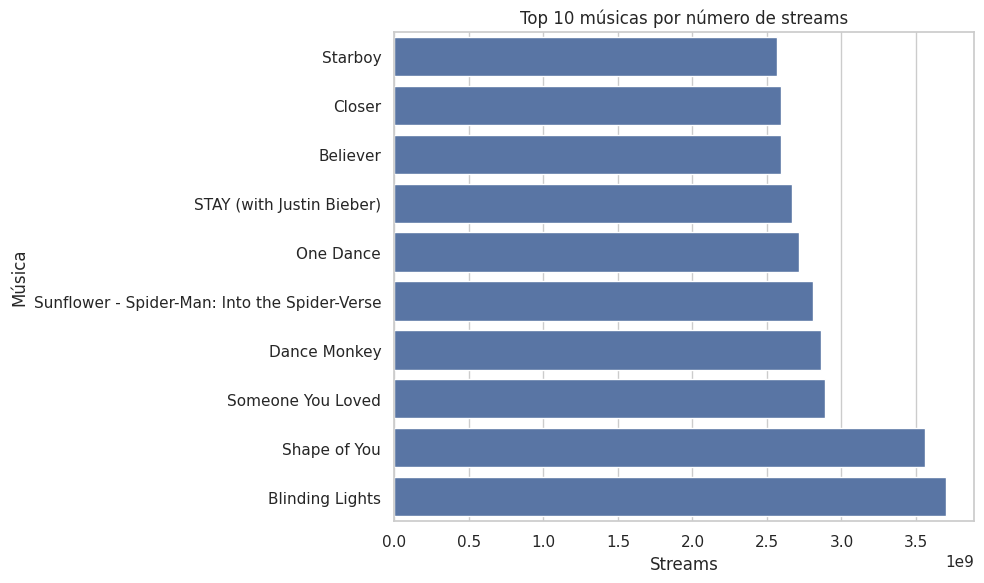

In [31]:
top_musicas = (
    df.nlargest(10, 'streams')
    [['track_name', 'artist(s)_name', 'streams']]
    .sort_values('streams')
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_musicas,
    x='streams',
    y='track_name'
)

plt.title('Top 10 músicas por número de streams')
plt.xlabel('Streams')
plt.ylabel('Música')

plt.tight_layout()
plt.show()

### Relação entre dançabilidade e energia

O gráfico permite observar visualmente se existe associação entre duas características musicais. Para quantificar essa relação, será calculado o coeficiente de correlação.

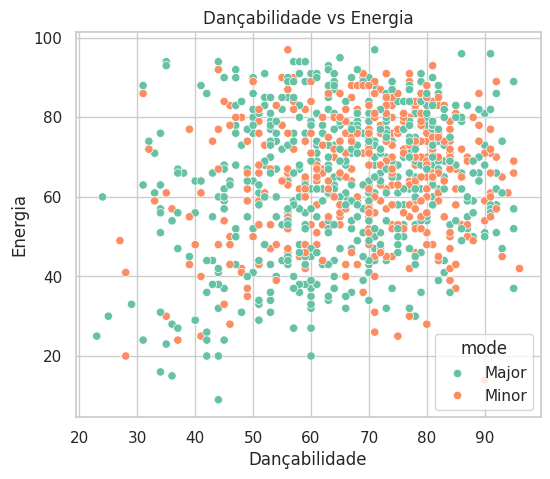

In [32]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x='danceability_%', y='energy_%', hue='mode', palette='Set2')
plt.title('Dançabilidade vs Energia')
plt.xlabel('Dançabilidade')
plt.ylabel('Energia')
plt.show()

In [33]:
df[['danceability_%', 'energy_%']].corr()

,danceability_%,energy_%
danceability_%,1.00,0.20
energy_%,0.20,1.00


A associação entre as variáveis é fraca, indicando que músicas mais dançantes não necessariamente apresentam maior energia

## 6. Relação entre Streams e Engajamento nas Plataformas
Nesta etapa, vamos investigar como o volume de reproduções (`streams`) se relaciona com a presença das faixas em playlists e paradas de diferentes plataformas (como Spotify, Apple Music e Deezer).

In [34]:
estatisticas_streams = df['streams'].describe()

estatisticas_streams

,streams
count,948.00
mean,"514,017,927.52"
std,"567,927,731.75"
min,"2,762.00"
25%,"141,143,862.00"
50%,"287,690,252.00"
75%,"672,942,469.00"
max,"3,703,895,074.00"


In [35]:
print(f"Média:   {df['streams'].mean():,.0f}")
print(f"Mediana: {df['streams'].median():,.0f}")
print(f"Assimetria: {df['streams'].skew():.2f}")

Média:   514,017,928
Mediana: 287,690,252
Assimetria: 2.00


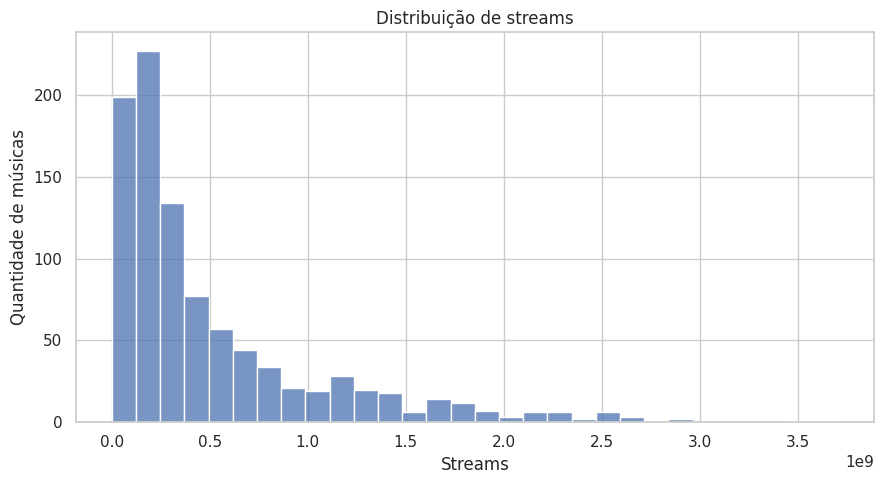

In [36]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='streams',
    bins=30
)

plt.title('Distribuição de streams')
plt.xlabel('Streams')
plt.ylabel('Quantidade de músicas')

plt.tight_layout()
plt.show()

In [37]:
df['log_streams'] = np.log1p(df['streams'])

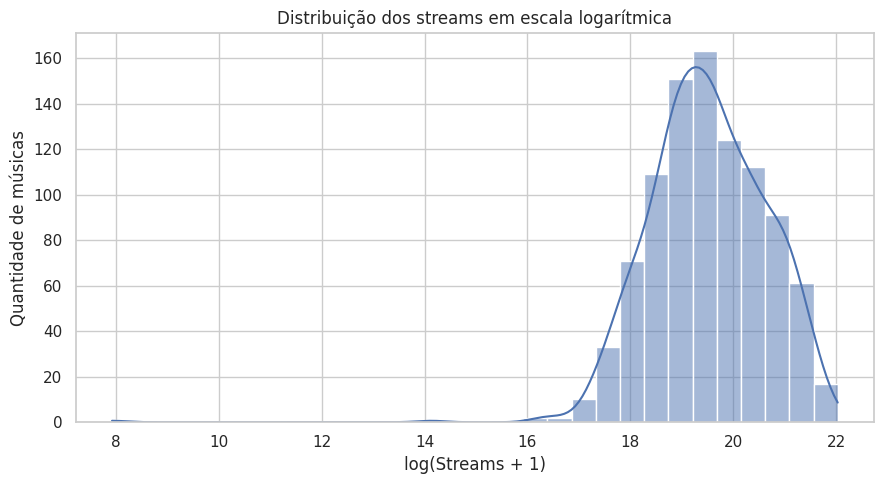

In [38]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='log_streams',
    bins=30,
    kde=True
)

plt.title('Distribuição dos streams em escala logarítmica')
plt.xlabel('log(Streams + 1)')
plt.ylabel('Quantidade de músicas')

plt.tight_layout()
plt.show()

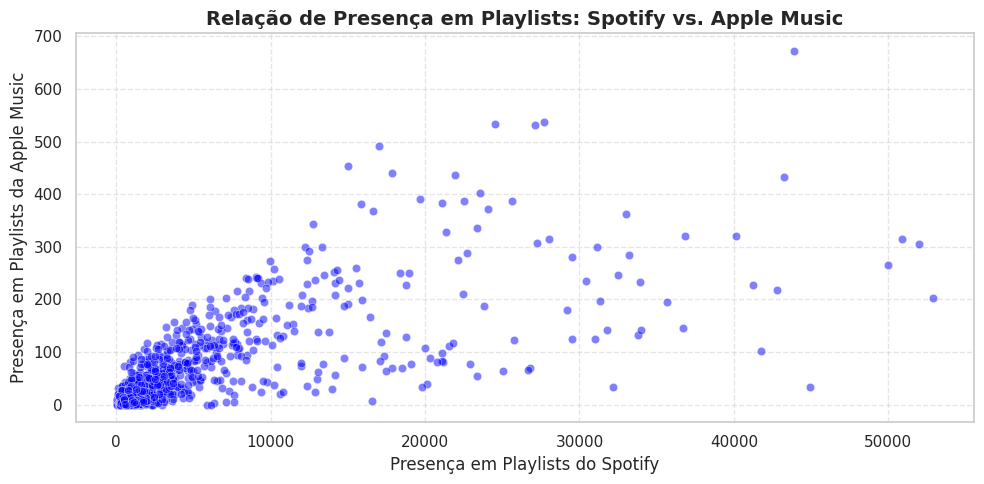

In [39]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='in_spotify_playlists', y='in_apple_playlists', alpha=0.5, color='blue')
plt.title('Relação de Presença em Playlists: Spotify vs. Apple Music', fontsize=14, fontweight='bold')
plt.xlabel('Presença em Playlists do Spotify', fontsize=12)
plt.ylabel('Presença em Playlists da Apple Music', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

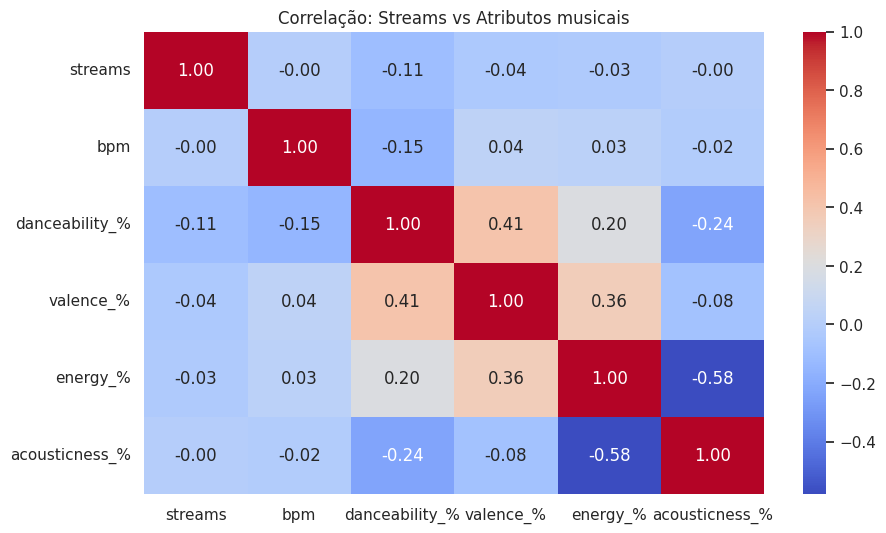

In [40]:
plt.figure(figsize=(10, 6))
cols_audio = ['streams', 'bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%']
sns.heatmap(df[cols_audio].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação: Streams vs Atributos musicais')
plt.show()

In [41]:
colunas_distribuicao = [
    'streams',
    'in_spotify_playlists',
    'in_apple_playlists',
    'in_deezer_playlists',
    'in_spotify_charts',
    'in_apple_charts',
    'in_deezer_charts',
    'in_shazam_charts'
]

corr_distribuicao = (
    df[colunas_distribuicao]
    .corr(method='spearman')['streams']
    .sort_values(ascending=False)
)

corr_distribuicao

,streams
streams,1.00
in_spotify_playlists,0.83
in_deezer_playlists,0.74
in_apple_playlists,0.67
in_apple_charts,0.34
in_spotify_charts,0.26
in_deezer_charts,0.23
in_shazam_charts,0.20


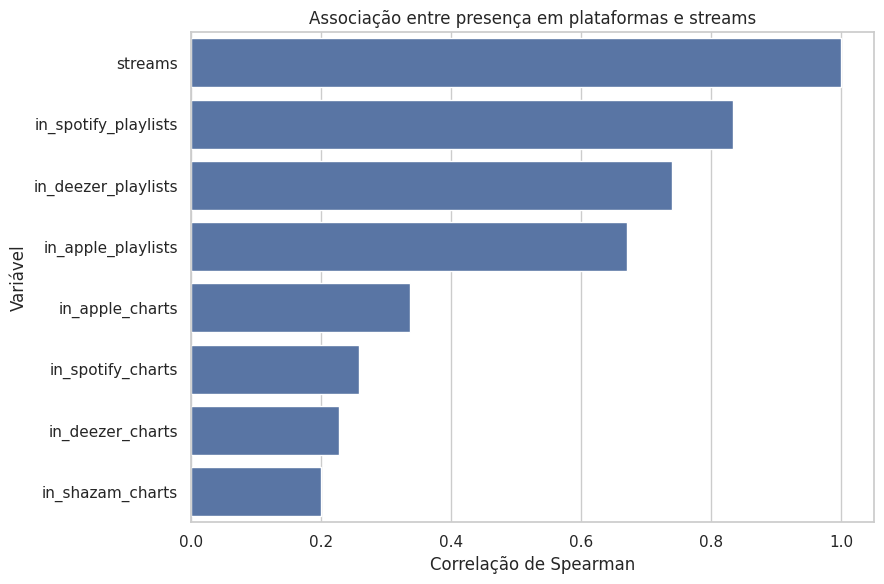

In [42]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=corr_distribuicao.values,
    y=corr_distribuicao.index
)

plt.title('Associação entre presença em plataformas e streams')
plt.xlabel('Correlação de Spearman')
plt.ylabel('Variável')

plt.tight_layout()
plt.show()

## 7. Características musicais × Streams

Agora vamos verificar se as características musicais apresentam associação relevante com o número de streams.

Como a distribuição de streams é bastante assimétrica, será utilizada também a correlação de Spearman, além da correlação de Pearson.

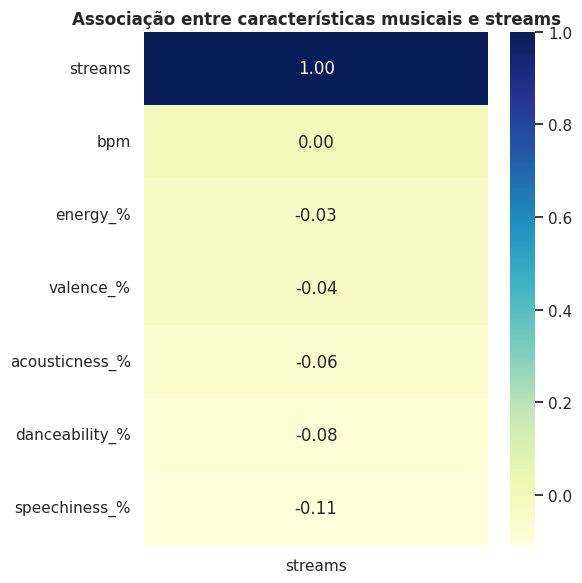

In [43]:
colunas_audio = [
    'streams',
    'bpm',
    'danceability_%',
    'valence_%',
    'energy_%',
    'acousticness_%',
    'speechiness_%'
]

matriz_corr = df[colunas_audio].corr(method='spearman')

plt.figure(figsize=(6, 6))

sns.heatmap(
    matriz_corr[['streams']].sort_values(
        by='streams',
        ascending=False
    ),
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title(
    'Associação entre características musicais e streams',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [44]:
streams_por_modo = (
    df.groupby('mode')['streams']
    .agg(['median', 'mean', 'count'])
)

streams_por_modo

,median,mean,count
mode,,,
Major,"301,494,871.00","535,123,195.53",546
Minor,"272,691,474.00","485,352,563.50",402


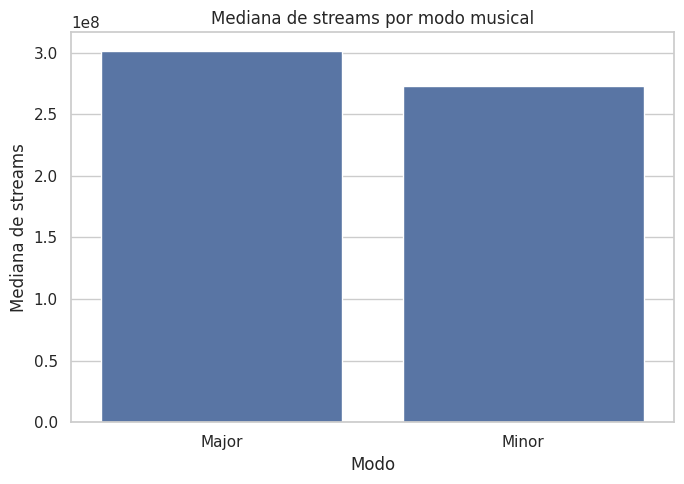

In [45]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=streams_por_modo.reset_index(),
    x='mode',
    y='median'
)

plt.title('Mediana de streams por modo musical')
plt.xlabel('Modo')
plt.ylabel('Mediana de streams')

plt.tight_layout()
plt.show()

In [46]:
pearson = (
    df[colunas_audio]
    .corr(method='pearson')['streams']
    .rename('pearson')
)

spearman = (
    df[colunas_audio]
    .corr(method='spearman')['streams']
    .rename('spearman')
)

comparacao_corr = pd.concat(
    [pearson, spearman],
    axis=1
)

comparacao_corr.sort_values(
    'spearman',
    ascending=False
)

,pearson,spearman
streams,1.00,1.00
bpm,-0.00,0.00
energy_%,-0.03,-0.03
valence_%,-0.04,-0.04
acousticness_%,-0.00,-0.06
danceability_%,-0.11,-0.08
speechiness_%,-0.11,-0.11


### Primeiros resultados

As características musicais analisadas apresentam associações relativamente limitadas com o número de streams quando comparadas às métricas relacionadas à distribuição das faixas.

Isso sugere que o desempenho de uma música não pode ser explicado apenas por suas características sonoras.

A próxima etapa é:

# A exposição e a distribuição apresentam associação maior com os streams do que as características musicais?

## 8. Distribuição × Streams

Após analisar as características musicais, vamos investigar se métricas de distribuição apresentam maior associação com o número de streams.

A hipótese é que músicas com maior presença em playlists e rankings podem apresentar maior volume de reproduções.

In [47]:
colunas_distribuicao= ['streams', 'in_spotify_playlists', 'in_apple_playlists', 'artist_count']
print(df[colunas_distribuicao].corr())

                      streams  in_spotify_playlists  in_apple_playlists  \
streams                  1.00                  0.79                0.77   
in_spotify_playlists     0.79                  1.00                0.71   
in_apple_playlists       0.77                  0.71                1.00   
artist_count            -0.14                 -0.10               -0.05   

                      artist_count  
streams                      -0.14  
in_spotify_playlists         -0.10  
in_apple_playlists           -0.05  
artist_count                  1.00  


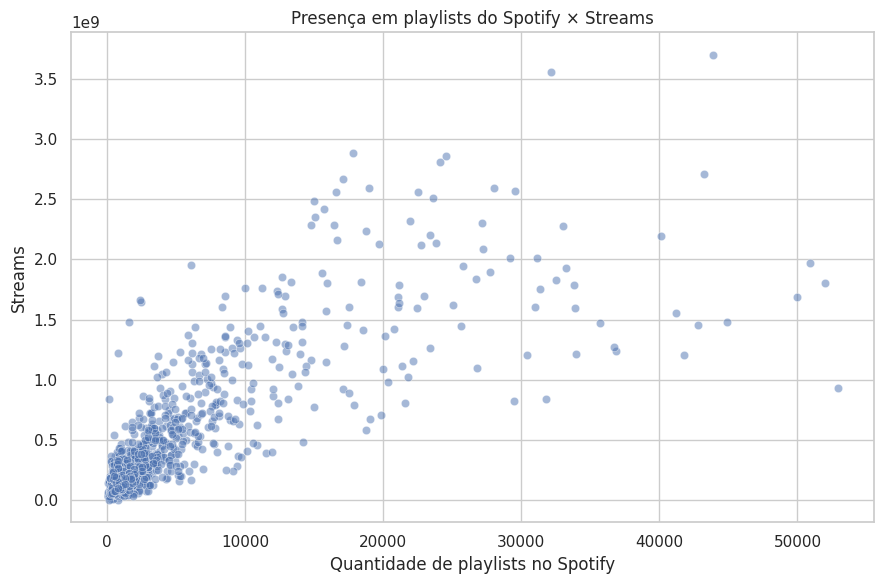

In [48]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='in_spotify_playlists',
    y='streams',
    alpha=0.5
)

plt.title(
    'Presença em playlists do Spotify × Streams'
)

plt.xlabel('Quantidade de playlists no Spotify')
plt.ylabel('Streams')

plt.tight_layout()
plt.show()

In [49]:
correlacao_distribuicao = (
    df[colunas_distribuicao]
    .corr(method='spearman')['streams']
    .sort_values(ascending=False)
)

correlacao_distribuicao

,streams
streams,1.00
in_spotify_playlists,0.83
in_apple_playlists,0.67
artist_count,-0.15


### Interpretação

Os resultados indicam uma associação positiva entre a presença de uma música em playlists e seu número de streams.

No entanto, essa relação não permite concluir que a presença em playlists cause diretamente o aumento de reproduções. Músicas mais populares também podem ser adicionadas com maior frequência às playlists.

## 9. Análise temporal

As músicas presentes no ranking não foram necessariamente lançadas em 2023.

Nesta etapa, vamos investigar:

- quais anos de lançamento aparecem na base;
- como os streams se distribuem de acordo com o ano;
- se existe diferença aparente entre músicas mais antigas e recentes;
- se o mês de lançamento apresenta alguma associação com desempenho.

> **Importante:** como streams são acumulados ao longo do tempo, músicas lançadas há mais tempo podem ter vantagem na quantidade total de reproduções.

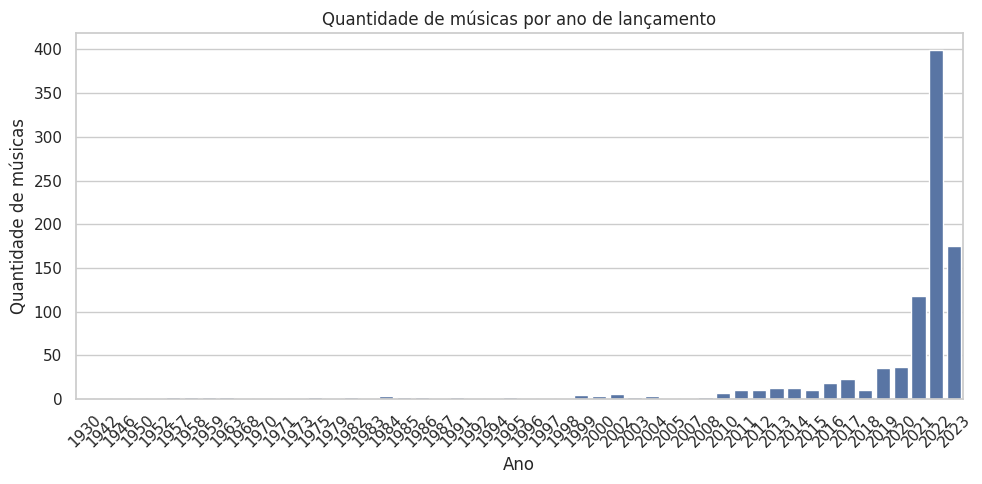

In [50]:
lancamentos_ano = (
    df['released_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=lancamentos_ano.index,
    y=lancamentos_ano.values
)

plt.title('Quantidade de músicas por ano de lançamento')
plt.xlabel('Ano')
plt.ylabel('Quantidade de músicas')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
streams_por_ano = (
    df.groupby('released_year')['streams']
    .agg(['median', 'mean', 'count'])
    .reset_index()
)

streams_por_ano

,released_year,median,mean,count
0,1930,"90,598,517.00","90,598,517.00",1
1,1942,"395,591,396.00","395,591,396.00",1
2,1946,"389,771,964.00","389,771,964.00",1
3,1950,"473,248,298.00","473,248,298.00",1
4,1952,"395,591,396.00","395,591,396.00",1
5,1957,"459,981,011.00","459,981,011.00",2
6,1958,"295,998,468.00","436,854,312.33",3
7,1959,"286,708,922.00","286,708,922.00",2
8,1963,"404,664,135.00","437,087,793.67",3
9,1968,"1,145,727,611.00","1,145,727,611.00",1


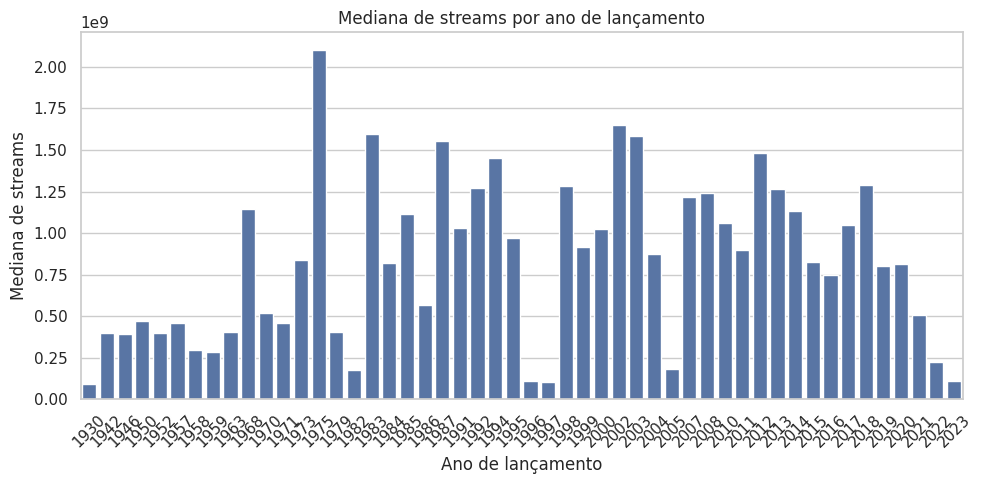

In [52]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=streams_por_ano,
    x='released_year',
    y='median'
)

plt.title('Mediana de streams por ano de lançamento')
plt.xlabel('Ano de lançamento')
plt.ylabel('Mediana de streams')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [53]:
sazonalidade = (
    df.groupby('released_month')['streams']
    .agg(['median', 'mean', 'count'])
    .reset_index()
)

sazonalidade

,released_month,median,mean,count
0,1,"500,340,342.00","727,506,136.92",133
1,2,"233,801,632.00","353,153,502.20",61
2,3,"223,633,238.00","474,295,973.48",85
3,4,"190,981,339.00","399,226,772.17",65
4,5,"230,577,871.50","415,669,054.50",128
5,6,"170,794,017.50","410,044,671.06",86
6,7,"354,748,772.50","482,176,477.66",62
7,8,"426,204,830.00","635,678,220.24",45
8,9,"414,941,972.50","734,644,353.11",56
9,10,"344,341,520.00","592,888,965.22",72


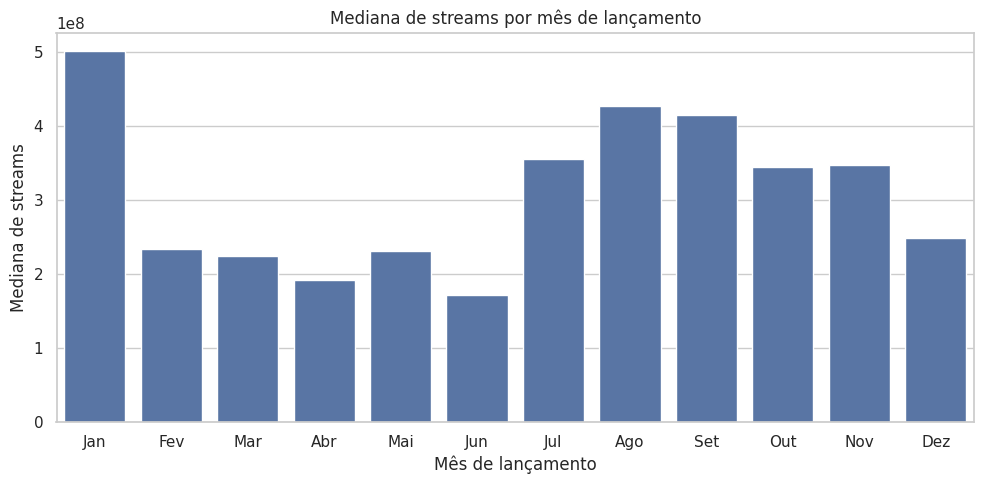

In [54]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=sazonalidade,
    x='released_month',
    y='median'
)

plt.title('Mediana de streams por mês de lançamento')
plt.xlabel('Mês de lançamento')
plt.ylabel('Mediana de streams')

meses = [
    'Jan', 'Fev', 'Mar', 'Abr',
    'Mai', 'Jun', 'Jul', 'Ago',
    'Set', 'Out', 'Nov', 'Dez'
]

plt.xticks(
    ticks=range(12),
    labels=meses
)

plt.tight_layout()
plt.show()

### Sazonalidade

Existem diferenças entre as medianas de streams das músicas lançadas em diferentes meses.

Entretanto, esses resultados não são suficientes para afirmar que determinado mês seja melhor para lançar uma música, pois o dataset contém músicas lançadas em anos diferentes e o número de streams é acumulado ao longo do tempo.

Por isso, o mês deve ser interpretado apenas como uma possível associação, e não como uma estratégia causal de lançamento.

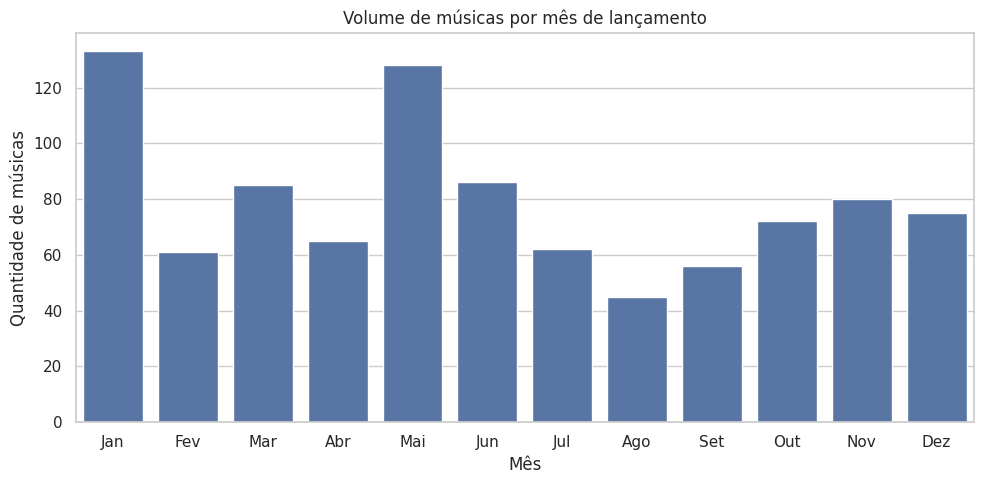

In [55]:
volume_lancamentos = (
    df['released_month']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=volume_lancamentos.index,
    y=volume_lancamentos.values
)

plt.title('Volume de músicas por mês de lançamento')
plt.xlabel('Mês')
plt.ylabel('Quantidade de músicas')

plt.xticks(
    ticks=range(12),
    labels=meses
)

plt.tight_layout()
plt.show()

## Vamos investigar: Quando lançar?

In [56]:
df_2023 = df[df['released_year'] == 2023].copy()

In [57]:
streams_2023_mes = (
    df_2023
    .groupby('released_month')['streams']
    .agg(['median', 'mean', 'count'])
    .reset_index()
)

streams_2023_mes

,released_month,median,mean,count
0,1,"153,454,328.00","287,635,463.79",19
1,2,"201,660,859.00","231,191,625.48",23
2,3,"127,567,540.00","170,092,261.59",37
3,4,"118,810,253.00","150,805,435.90",21
4,5,"81,102,253.00","94,420,746.38",29
5,6,"59,560,864.50","70,200,253.44",32
6,7,"33,729,503.00","41,504,665.57",14


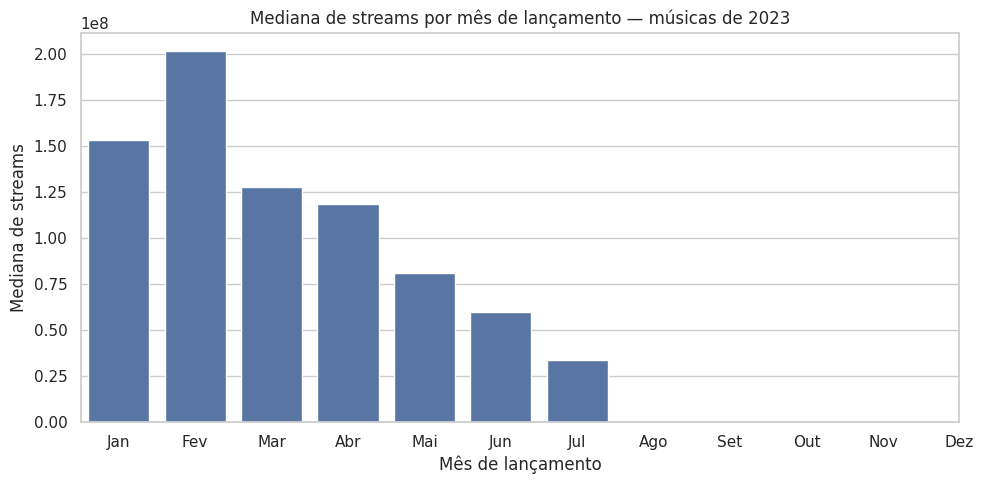

In [58]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=streams_2023_mes,
    x='released_month',
    y='median'
)

plt.title('Mediana de streams por mês de lançamento — músicas de 2023')
plt.xlabel('Mês de lançamento')
plt.ylabel('Mediana de streams')

plt.xticks(
    ticks=range(12),
    labels=[
        'Jan', 'Fev', 'Mar', 'Abr',
        'Mai', 'Jun', 'Jul', 'Ago',
        'Set', 'Out', 'Nov', 'Dez'
    ]
)

plt.tight_layout()
plt.show()

## Os artistas que aparecem mais vezes também possuem maior volume de streams?

In [59]:
artista_streams = (
    df.assign(
        artist=df['artist(s)_name']
        .str.split(',')
    )
    .explode('artist')
)

artista_streams['artist'] = (
    artista_streams['artist']
    .str.strip()
)

top_artistas_streams = (
    artista_streams
    .groupby('artist')['streams']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

top_artistas_streams

,streams
artist,
Tones and I,"2,864,791,672.00"
Kyla,"2,713,922,350.00"
Glass Animals,"2,557,975,762.00"
The Chainsmokers,"2,397,652,496.00"
Queen,"2,197,010,679.00"
Bradley Cooper,"2,159,346,687.00"
Hozier,"2,135,158,446.00"
Vance Joy,"2,009,094,673.00"
Ray Dalton,"1,953,533,826.00"


## 10. Principais Insights

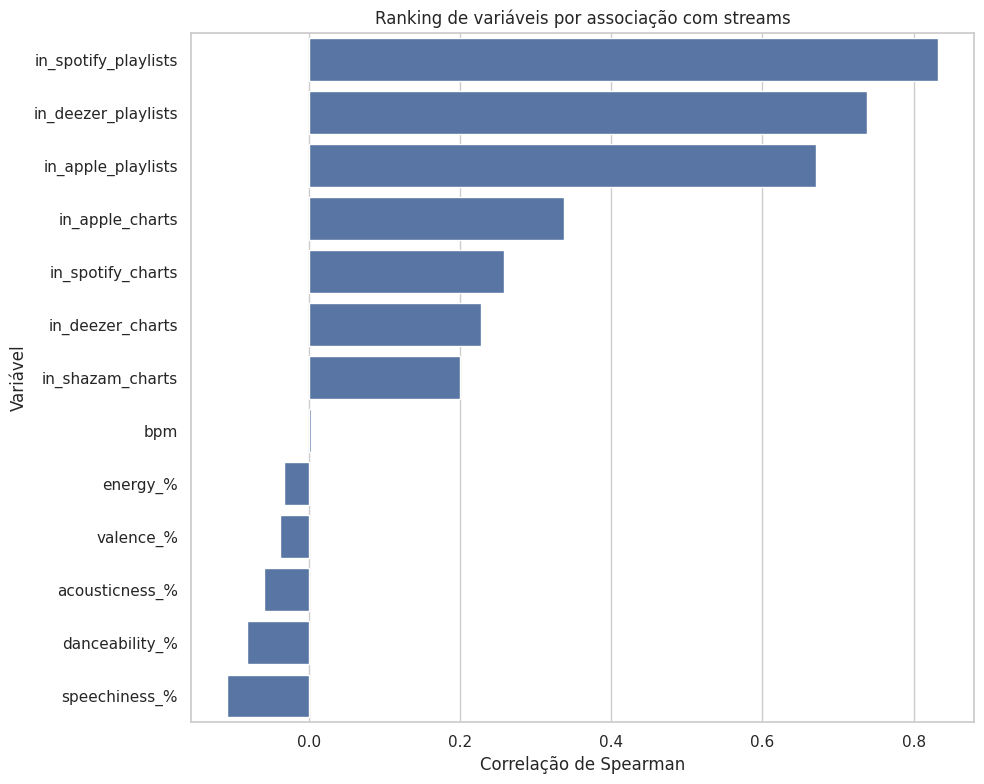

In [60]:
variaveis = [
    'in_spotify_playlists',
    'in_apple_playlists',
    'in_deezer_playlists',
    'in_spotify_charts',
    'in_apple_charts',
    'in_deezer_charts',
    'in_shazam_charts',
    'danceability_%',
    'energy_%',
    'valence_%',
    'acousticness_%',
    'speechiness_%',
    'bpm'
]

correlacoes = (
    df[variaveis + ['streams']]
    .corr(method='spearman')['streams']
    .drop('streams')
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=correlacoes.values,
    y=correlacoes.index
)

plt.title(
    'Ranking de variáveis por associação com streams'
)

plt.xlabel('Correlação de Spearman')
plt.ylabel('Variável')

plt.tight_layout()
plt.show()

### 🎧 1. Características musicais não explicam sozinhas o sucesso

As correlações entre streams e características como energia, dançabilidade, valência e BPM são limitadas.

Isso indica que o desempenho de uma música não pode ser explicado apenas por seus atributos sonoros.

### 📈 2. Métricas de distribuição apresentam associações mais relevantes

A presença das músicas em playlists e rankings apresenta associações mais fortes com streams do que várias das características musicais analisadas.

Isso sugere que exposição e distribuição podem desempenhar um papel importante no desempenho observado.

### 👤 3. Alguns artistas concentram várias músicas do ranking

A análise de frequência mostra que determinados artistas aparecem repetidamente entre as faixas presentes no dataset.

Entretanto, quantidade de aparições não significa necessariamente maior média ou mediana de streams.

### 📅 4. O período de lançamento exige cautela na interpretação

Existem diferenças nos streams de acordo com o período de lançamento, mas músicas mais antigas tiveram mais tempo para acumular reproduções.

Por isso, não é possível concluir apenas com esta análise que determinado mês ou ano seja causalmente melhor para lançar uma música.

### ⚠️ 5. Correlação não significa causalidade

As associações encontradas mostram relações entre variáveis, mas não permitem afirmar que uma variável seja responsável diretamente pelo aumento de streams.

## 11. Limitações da análise

Algumas limitações devem ser consideradas ao interpretar os resultados:

- O dataset contém músicas presentes em um ranking específico, não uma amostra de todas as músicas disponíveis no Spotify.
- O número de streams é acumulado e favorece músicas que estão disponíveis há mais tempo.
- Correlação não implica causalidade.
- Não há informações sobre investimento em marketing, campanhas promocionais ou orçamento dos artistas.
- A presença em playlists pode ser consequência da popularidade da música, e não necessariamente sua causa.
- Algumas variáveis apresentam valores ausentes.
- A análise é exploratória e não pretende estabelecer relações causais.

## 🔎 Próximos passos

Algumas extensões poderiam aprofundar esta análise:

- analisar a relação entre streams e tempo desde o lançamento;
- comparar músicas lançadas em 2023 separadamente;
- investigar diferenças entre artistas e gêneros musicais;
- construir modelos estatísticos para estimar o número de streams;
- incorporar dados externos relacionados a popularidade, marketing e redes sociais.